# Лабораторна 3. Класифікація зображень (CNN)
### Шальман Тимофій КА-35

## Варіант 15 (Tiny ImageNet - 200 класів)

In [1]:
import pandas as pd

splits = {
    'train': 'data/train-00000-of-00001-1359597a978bc4fa.parquet', 
    'valid': 'data/valid-00000-of-00001-70d52db3c749a935.parquet'
    }

df_train = pd.read_parquet("hf://datasets/zh-plus/tiny-imagenet/" + splits["train"])
df_valid = pd.read_parquet("hf://datasets/zh-plus/tiny-imagenet/" + splits["valid"])

In [ ]:
df_train.shape, df_valid.shape

((100000, 2), (10000, 2))

In [ ]:
df_train.head()

,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


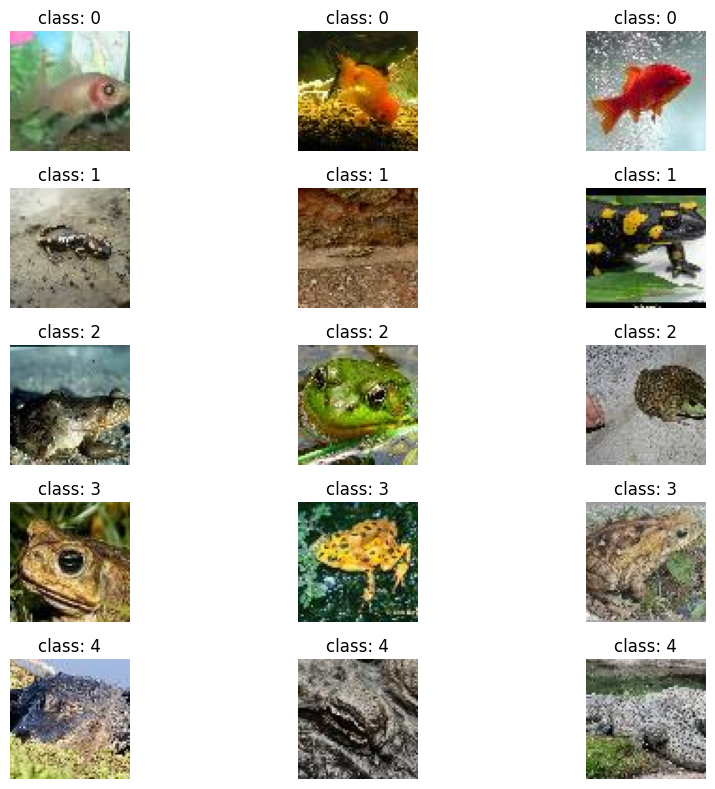

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import io

classes = sorted(df_train["label"].unique())[:5]

plt.figure(figsize=(10, 8))
plot_idx = 1

for cls in classes:
    samples = df_train[df_train["label"] == cls].head(3)
    
    for _, row in samples.iterrows():
        img_dict = row["image"]
        
        # беремо bytes з dict
        image = Image.open(io.BytesIO(img_dict["bytes"])).convert("RGB")
        
        plt.subplot(len(classes), 3, plot_idx)
        plt.imshow(image)
        plt.title(f"class: {cls}")
        plt.axis("off")
        
        plot_idx += 1

plt.tight_layout()
plt.show()

### Dataset клас

In [3]:
import torch
from torch.utils.data import Dataset
import numpy as np
from PIL import Image
import io

class TinyImageNetDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        label = row['label']
        image_bytes = row['image']["bytes"]
        image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
        
        if self.transform:
            image = self.transform(image)

        return image, label

### Аугментації

In [4]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.RandomResizedCrop(64),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

valid_tfms = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

### DataLoader

In [5]:
from torch.utils.data import DataLoader

train_dataset = TinyImageNetDataset(df_train, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

valid_dataset = TinyImageNetDataset(df_valid, transform=valid_tfms)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

## Тренування моделі ResNet18

In [6]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 200)

In [7]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    
    total_loss = 0
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    pbar = tqdm(dataloader, desc="Train", leave=False)

    for x, y in pbar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Top-1
        _, pred = outputs.max(1)
        correct_top1 += (pred == y).sum().item()

        # Top-5
        _, top5 = outputs.topk(5, dim=1)
        correct_top5 += (top5 == y.view(-1, 1)).sum().item()

        total += y.size(0)

        lr = optimizer.param_groups[0]['lr']

        pbar.set_postfix({
            "loss": total_loss / (total / y.size(0)),
            "top1": correct_top1 / total,
            "top5": correct_top5 / total,
            "lr": lr
        })

    return {
        "loss": total_loss / len(dataloader),
        "top1": correct_top1 / total,
        "top5": correct_top5 / total
    }

In [9]:
from sklearn.metrics import f1_score, confusion_matrix

def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    all_preds = []
    all_targets = []

    pbar = tqdm(dataloader, desc="Eval", leave=False)

    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()

            # Top-1
            _, pred = outputs.max(1)
            correct_top1 += (pred == y).sum().item()

            # Top-5
            _, top5 = outputs.topk(5, dim=1)
            correct_top5 += (top5 == y.view(-1, 1)).sum().item()

            total += y.size(0)

            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

            pbar.set_postfix({
                "loss": total_loss / (total / y.size(0)),
                "top1": correct_top1 / total,
                "top5": correct_top5 / total
            })

    f1 = f1_score(all_targets, all_preds, average="macro")
    cm = confusion_matrix(all_targets, all_preds)

    return {
        "loss": total_loss / len(dataloader),
        "top1": correct_top1 / total,
        "top5": correct_top5 / total,
        "f1": f1,
        "confusion_matrix": cm
    }

In [10]:
import os

# Директорія для збереження моделі
save_dir = "./models/resnet18"
os.makedirs(save_dir, exist_ok=True)

### Тренування з Cosine Scheduler

In [13]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import time


device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"device: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

num_epochs = 10

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-5  # мінімальний LR
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_top1": [],
    "val_top1": [],
}

for epoch in range(num_epochs):
    start_epoch = time.time()
    
    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()

    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate(model, valid_loader, criterion, device)

    scheduler.step()
    
    epoch_time = time.time() - start_epoch

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_top1"].append(train_metrics["top1"])
    history["val_top1"].append(val_metrics["top1"])
    
    print(f"Epoch {epoch+1}/{num_epochs} | Time: {epoch_time:.2f}s")
    print(f"Train Loss: {train_metrics['loss']:.4f} | Top1: {train_metrics['top1']:.4f} | Top5: {train_metrics['top5']:.4f}")
    print(f"Val   Loss: {val_metrics['loss']:.4f} | Top1: {val_metrics['top1']:.4f} | Top5: {val_metrics['top5']:.4f} | F1: {val_metrics['f1']:.4f}")

    if device == "cuda":
        mem = torch.cuda.max_memory_allocated() / 1024**2
        print(f"GPU memory: {mem:.2f} MB")

# Збереження моделі
torch.save(model.state_dict(), f"{save_dir}/resnet18.pth")

device: cuda


Epoch 1/10 | Time: 155.38s
Train Loss: 3.4604 | Top1: 0.2310 | Top5: 0.4752
Val   Loss: 3.4368 | Top1: 0.2412 | Top5: 0.4941 | F1: 0.2282
GPU memory: 484.97 MB


Epoch 2/10 | Time: 153.07s
Train Loss: 3.3754 | Top1: 0.2435 | Top5: 0.4939
Val   Loss: 3.2513 | Top1: 0.2722 | Top5: 0.5288 | F1: 0.2545
GPU memory: 483.91 MB


Epoch 3/10 | Time: 157.06s
Train Loss: 3.2705 | Top1: 0.2622 | Top5: 0.5169
Val   Loss: 3.0969 | Top1: 0.2989 | Top5: 0.5600 | F1: 0.2811
GPU memory: 483.91 MB


Epoch 4/10 | Time: 154.01s
Train Loss: 3.1657 | Top1: 0.2823 | Top5: 0.5384
Val   Loss: 2.9460 | Top1: 0.3259 | Top5: 0.5913 | F1: 0.3131
GPU memory: 483.91 MB


...

Epoch 6/10 | Time: 154.66s
Train Loss: 2.9588 | Top1: 0.3204 | Top5: 0.5798
Val   Loss: 2.7903 | Top1: 0.3569 | Top5: 0.6270 | F1: 0.3476
GPU memory: 483.91 MB


Epoch 7/10 | Time: 153.42s
Train Loss: 2.8506 | Top1: 0.3402 | Top5: 0.6028
Val   Loss: 2.7847 | Top1: 0.3560 | Top5: 0.6255 | F1: 0.3461
GPU memory: 483.91 MB


Epoch 8/10 | Time: 157.54s
Train Loss: 2.7684 | Top1: 0.3552 | Top5: 0.6180
Val   Loss: 2.7107 | Top1: 0.3674 | Top5: 0.6417 | F1: 0.3600
GPU memory: 483.91 MB


Epoch 9/10 | Time: 158.26s
Train Loss: 2.6992 | Top1: 0.3689 | Top5: 0.6318
Val   Loss: 2.6246 | Top1: 0.3881 | Top5: 0.6551 | F1: 0.3799
GPU memory: 483.91 MB


Epoch 10/10 | Time: 156.06s
Train Loss: 2.6622 | Top1: 0.3768 | Top5: 0.6374
Val   Loss: 2.6271 | Top1: 0.3881 | Top5: 0.6595 | F1: 0.3788
GPU memory: 483.91 MB


### Performance
*(#параметрів (М), FLOPs (Г), latency інференсу (CPU/GPU))*

In [16]:
from thop import profile

def get_model_stats(model, device):
    model.eval()
    dummy = torch.randn(1, 3, 64, 64).to(device)

    flops, params = profile(model, inputs=(dummy,), verbose=False)

    flops = flops / 1e9  # GFLOPs
    params = params / 1e6  # млн параметрів

    return flops, params

In [17]:
flops, params = get_model_stats(model, device)

print(f"Params: {params:.2f} M")
print(f"FLOPs: {flops:.2f} GFLOPs")

Params: 11.28 M
FLOPs: 0.15 GFLOPs


In [25]:
def measure_latency(model, device, runs=100):
    model.to(device)
    model.eval()
    dummy = torch.randn(1, 3, 64, 64).to(device)

    # warm-up
    for _ in range(10):
        _ = model(dummy)

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.time()
    for _ in range(runs):
        _ = model(dummy)

    if device == "cuda":
        torch.cuda.synchronize()
    
    end = time.time()

    return (end - start) / runs * 1000  # ms

In [28]:
lat_gpu = measure_latency(model, "cuda") if torch.cuda.is_available() else None
lat_cpu = measure_latency(model.to("cpu"), "cpu")

print(f"Latency CPU: {lat_cpu:.2f} ms")
if lat_gpu:
    print(f"Latency GPU: {lat_gpu:.2f} ms")

Latency CPU: 8.95 ms
Latency GPU: 3.13 ms


### Результати

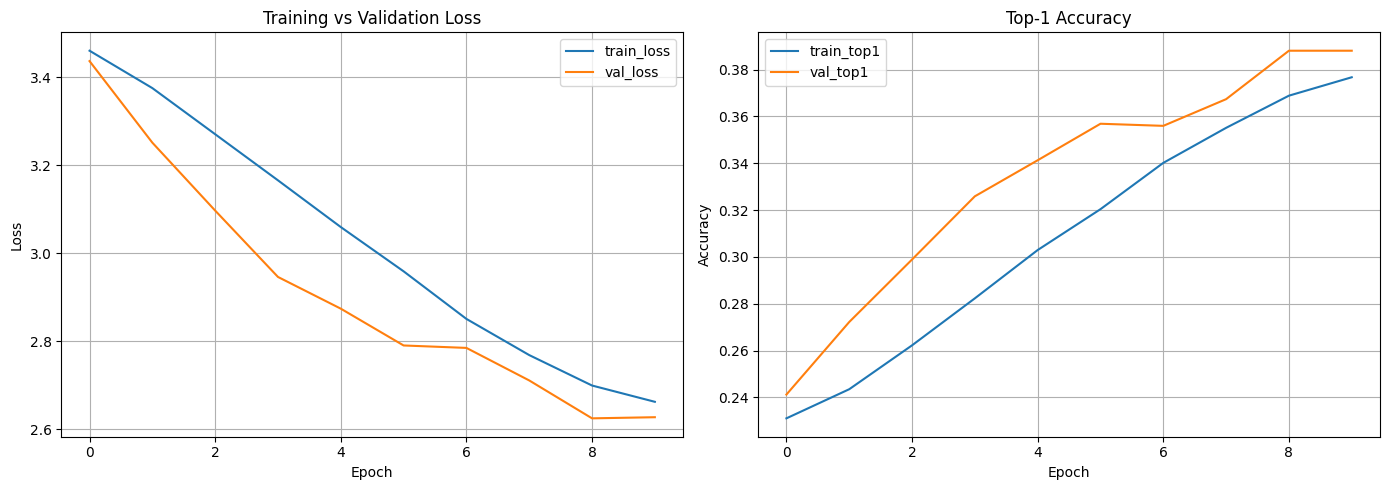

In [29]:
plt.figure(figsize=(14,5))

# Графік loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

# Графік accuracy
plt.subplot(1, 2, 2)
plt.plot(history["train_top1"], label="train_top1")
plt.plot(history["val_top1"], label="val_top1")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Top-1 Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

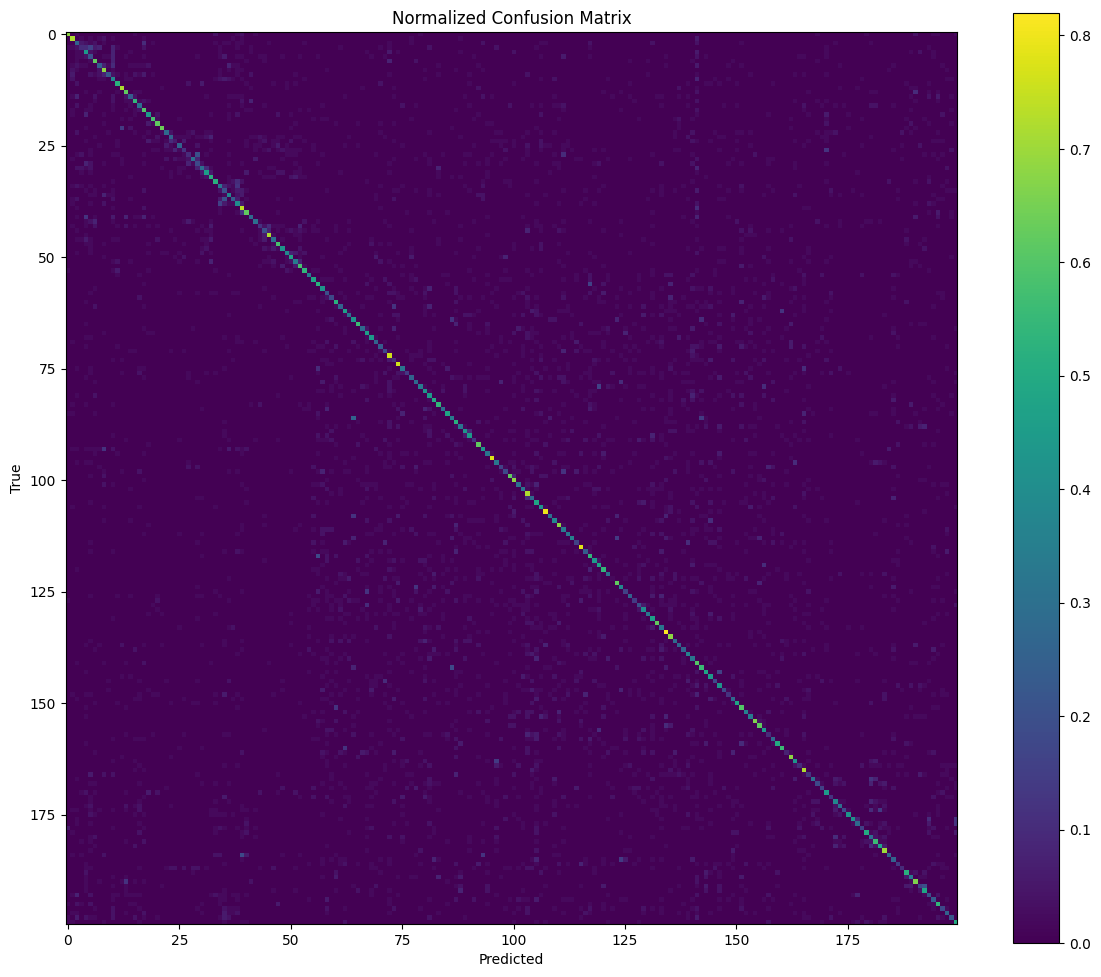

In [30]:
cm = val_metrics["confusion_matrix"]

# нормалізація по рядках (true labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, interpolation='nearest')
plt.title("Normalized Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

### Grad-CAM

In [31]:
target_layer = model.layer4

In [41]:
def compute_heatmap(model, img):
    model.to(device)
    model.eval()

    activations = []
    gradients = []

    # hook для збереження активацій
    def forward_hook(module, input, output):
        activations.append(output)

    # hook для градієнтів
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    # реєструємо hooks
    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)

    # forward
    logits = model(img)
    pred = logits.argmax(dim=1)

    # backward по predicted класу
    model.zero_grad()
    logits[0, pred].backward()

    # отримуємо активації і градієнти
    acts = activations[0]
    grads = gradients[0]

    # global average pooling градієнтів
    weights = grads.mean(dim=(2, 3), keepdim=True)

    # зважена сума
    heatmap = (weights * acts).sum(dim=1)[0]

    # ReLU
    heatmap = torch.relu(heatmap)

    # нормалізація
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # очищаємо hooks
    handle_f.remove()
    handle_b.remove()

    return heatmap.detach().cpu(), pred.item()

In [42]:
import cv2
import numpy as np

def upsampleHeatmap(heatmap, image):
    heatmap = heatmap.numpy()

    # resize до розміру картинки
    heatmap = cv2.resize(heatmap, (image.shape[2], image.shape[3]))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # tensor → numpy
    img = image[0].cpu().permute(1, 2, 0).numpy()

    # денормалізація
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    img = np.uint8(255 * img)

    # overlay
    overlay = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)

    return overlay

In [43]:
import matplotlib.pyplot as plt

def display_images(overlay, image):
    img = image[0].cpu().permute(1, 2, 0).numpy()

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.92156863].


Pred: 88, True: 32


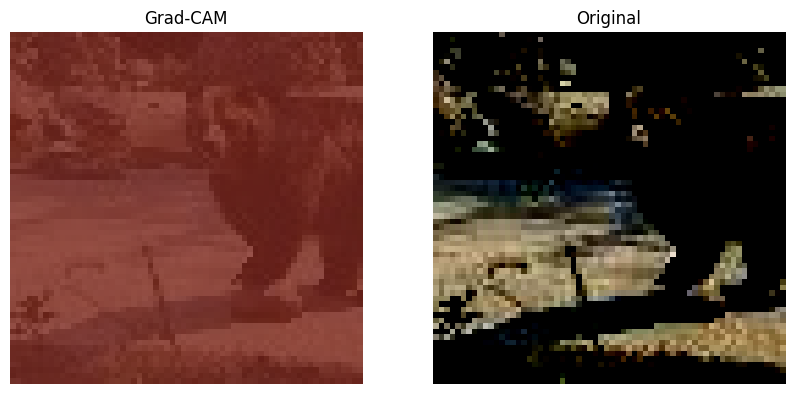

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Pred: 86, True: 142


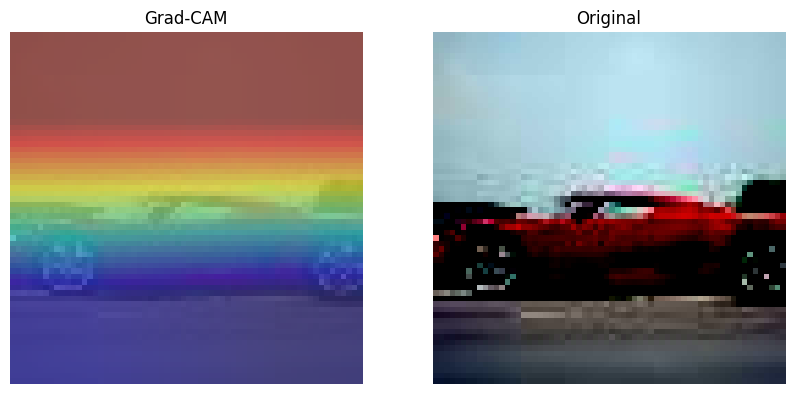

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Pred: 190, True: 190


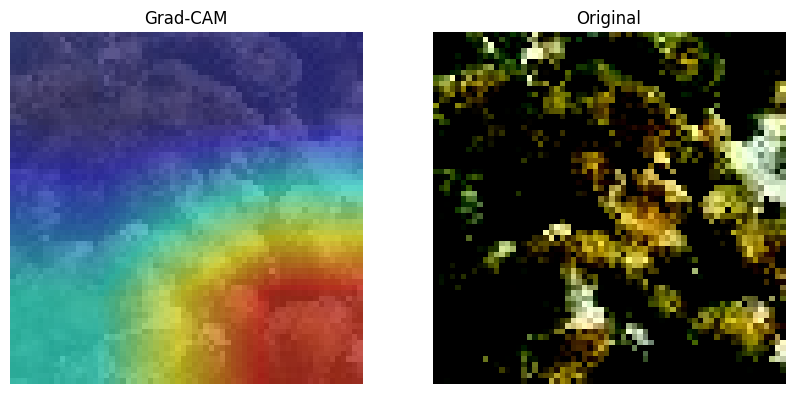

Pred: 131, True: 90


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


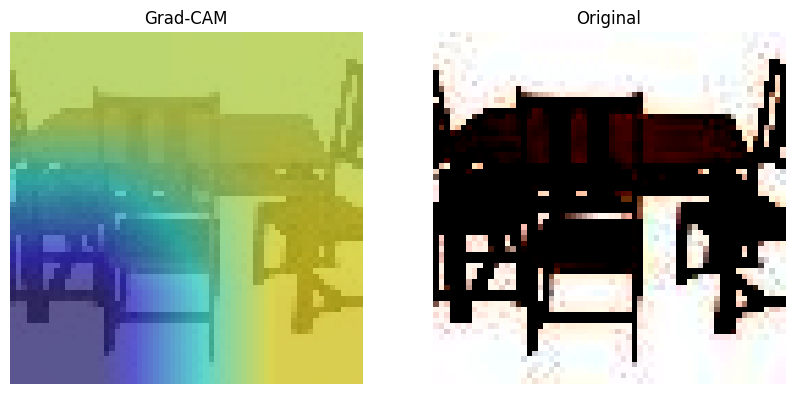

In [44]:
import random

model.eval()

for _ in range(4):  # 4 випадкові приклади
    idx = random.randint(0, len(valid_dataset) - 1)

    img, label = valid_dataset[idx]
    img = img.unsqueeze(0).to(device)

    heatmap, pred = compute_heatmap(model, img)
    overlay = upsampleHeatmap(heatmap, img)

    print(f"Pred: {pred}, True: {label}")

    display_images(overlay, img)

## Transfer learning ResNet18

In [45]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 200)

In [46]:
for param in model.parameters():
    param.requires_grad = False

# розморожуємо тільки останній шар
for param in model.fc.parameters():
    param.requires_grad = True

In [48]:
# ImageNet нормалізація

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(64),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

valid_tfms = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [49]:
train_dataset = TinyImageNetDataset(df_train, transform=train_tfms)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

valid_dataset = TinyImageNetDataset(df_valid, transform=valid_tfms)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

In [50]:
import os

# Директорія для збереження моделі
save_dir = "./models/resnet18"
os.makedirs(save_dir, exist_ok=True)

In [51]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import time


device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"device: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

num_epochs = 10

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-5  # мінімальний LR
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_top1": [],
    "val_top1": [],
}

for epoch in range(num_epochs):
    start_epoch = time.time()
    
    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()

    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate(model, valid_loader, criterion, device)

    scheduler.step()
    
    epoch_time = time.time() - start_epoch

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_top1"].append(train_metrics["top1"])
    history["val_top1"].append(val_metrics["top1"])
    
    print(f"Epoch {epoch+1}/{num_epochs} | Time: {epoch_time:.2f}s")
    print(f"Train Loss: {train_metrics['loss']:.4f} | Top1: {train_metrics['top1']:.4f} | Top5: {train_metrics['top5']:.4f}")
    print(f"Val   Loss: {val_metrics['loss']:.4f} | Top1: {val_metrics['top1']:.4f} | Top5: {val_metrics['top5']:.4f} | F1: {val_metrics['f1']:.4f}")

    if device == "cuda":
        mem = torch.cuda.max_memory_allocated() / 1024**2
        print(f"GPU memory: {mem:.2f} MB")

# Збереження моделі
torch.save(model.state_dict(), f"{save_dir}/tl_resnet18.pth")

device: cuda


Epoch 1/10 | Time: 83.13s
Train Loss: 3.6419 | Top1: 0.2368 | Top5: 0.4654
Val   Loss: 3.3362 | Top1: 0.2948 | Top5: 0.5564 | F1: 0.2890
GPU memory: 372.09 MB


Epoch 2/10 | Time: 78.12s
Train Loss: 3.3396 | Top1: 0.2847 | Top5: 0.5336
Val   Loss: 3.2520 | Top1: 0.3183 | Top5: 0.5796 | F1: 0.3151
GPU memory: 372.09 MB


Epoch 3/10 | Time: 77.67s
Train Loss: 3.2705 | Top1: 0.2961 | Top5: 0.5460
Val   Loss: 3.2863 | Top1: 0.3145 | Top5: 0.5796 | F1: 0.3100
GPU memory: 372.09 MB


Epoch 4/10 | Time: 74.91s
Train Loss: 3.2361 | Top1: 0.3018 | Top5: 0.5518
Val   Loss: 3.2317 | Top1: 0.3259 | Top5: 0.5826 | F1: 0.3211
GPU memory: 372.09 MB


...

Epoch 6/10 | Time: 75.03s
Train Loss: 3.1254 | Top1: 0.3167 | Top5: 0.5707
Val   Loss: 3.2207 | Top1: 0.3248 | Top5: 0.5787 | F1: 0.3213
GPU memory: 372.09 MB


Epoch 7/10 | Time: 75.19s
Train Loss: 3.0858 | Top1: 0.3233 | Top5: 0.5766
Val   Loss: 3.0896 | Top1: 0.3368 | Top5: 0.5971 | F1: 0.3323
GPU memory: 372.09 MB


Epoch 8/10 | Time: 75.61s
Train Loss: 3.0383 | Top1: 0.3292 | Top5: 0.5853
Val   Loss: 3.0857 | Top1: 0.3370 | Top5: 0.5936 | F1: 0.3293
GPU memory: 372.09 MB


Epoch 9/10 | Time: 79.96s
Train Loss: 3.0116 | Top1: 0.3336 | Top5: 0.5895
Val   Loss: 3.0296 | Top1: 0.3446 | Top5: 0.6011 | F1: 0.3394
GPU memory: 372.09 MB


Epoch 10/10 | Time: 78.15s
Train Loss: 2.9966 | Top1: 0.3365 | Top5: 0.5929
Val   Loss: 3.0006 | Top1: 0.3484 | Top5: 0.6064 | F1: 0.3448
GPU memory: 372.09 MB


### Performance
*(#параметрів (М), FLOPs (Г), latency інференсу (CPU/GPU))*

In [52]:
flops, params = get_model_stats(model, device)

print(f"Params: {params:.2f} M")
print(f"FLOPs: {flops:.2f} GFLOPs")

Params: 11.28 M
FLOPs: 0.15 GFLOPs


In [53]:
lat_gpu = measure_latency(model, "cuda") if torch.cuda.is_available() else None
lat_cpu = measure_latency(model.to("cpu"), "cpu")

print(f"Latency CPU: {lat_cpu:.2f} ms")
if lat_gpu:
    print(f"Latency GPU: {lat_gpu:.2f} ms")

Latency CPU: 8.97 ms
Latency GPU: 2.91 ms


### Результати

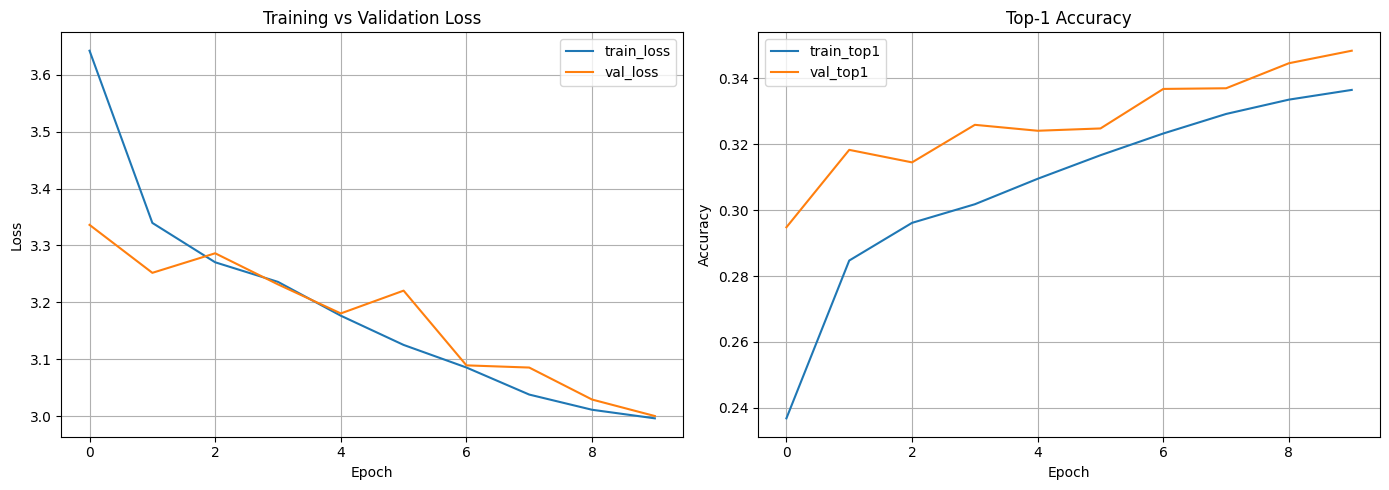

In [54]:
plt.figure(figsize=(14,5))

# Графік loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

# Графік accuracy
plt.subplot(1, 2, 2)
plt.plot(history["train_top1"], label="train_top1")
plt.plot(history["val_top1"], label="val_top1")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Top-1 Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

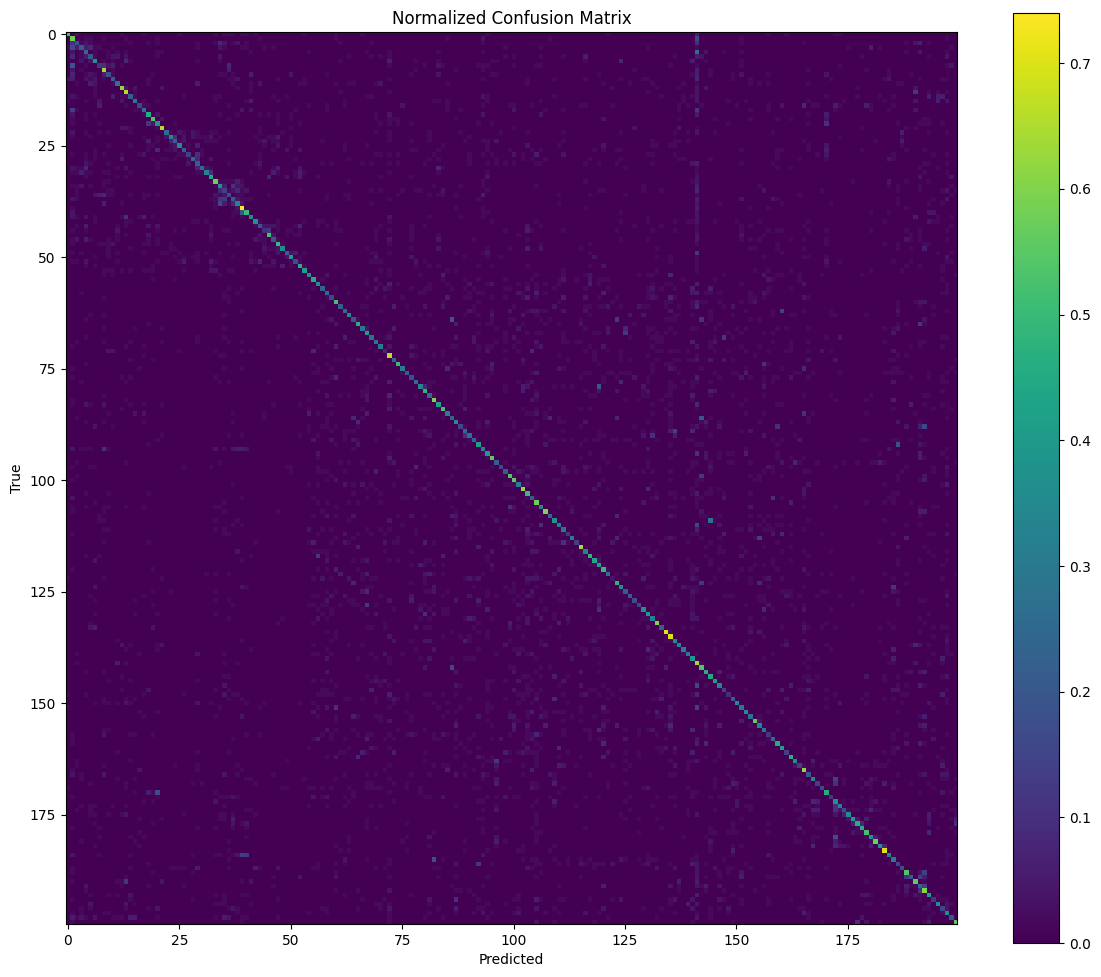

In [55]:
cm = val_metrics["confusion_matrix"]

# нормалізація по рядках (true labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, interpolation='nearest')
plt.title("Normalized Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

### Grad-CAM

In [56]:
target_layer = model.layer4[-1].conv2

In [59]:
def compute_heatmap(model, img):
    model.to(device)
    model.eval()

    img = img.clone().detach().requires_grad_(True)

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    logits = model(img)
    pred = logits.argmax(dim=1).item()

    model.zero_grad(set_to_none=True)
    logits[0, pred].backward()

    if len(activations) == 0 or len(gradients) == 0:
        handle_f.remove()
        handle_b.remove()
        raise RuntimeError("Hooks did not capture activations/gradients. Check target_layer.")

    acts = activations[0]
    grads = gradients[0]

    weights = grads.mean(dim=(2, 3), keepdim=True)
    heatmap = (weights * acts).sum(dim=1)[0]
    heatmap = torch.relu(heatmap)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    handle_f.remove()
    handle_b.remove()

    return heatmap.detach().cpu(), pred

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].


Pred: 130, True: 67


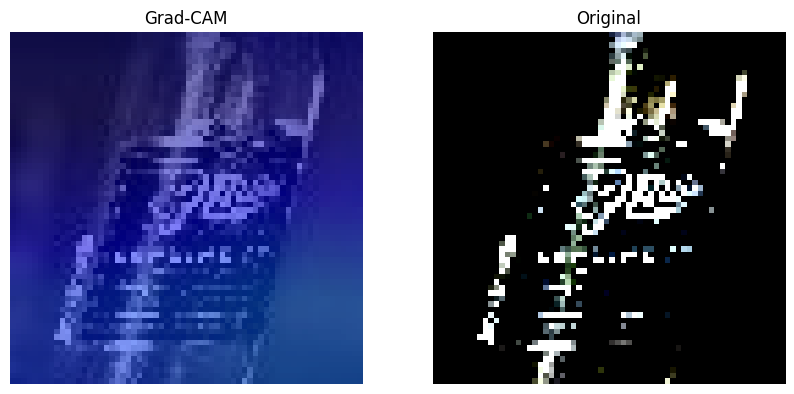

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..2.64].


Pred: 57, True: 57


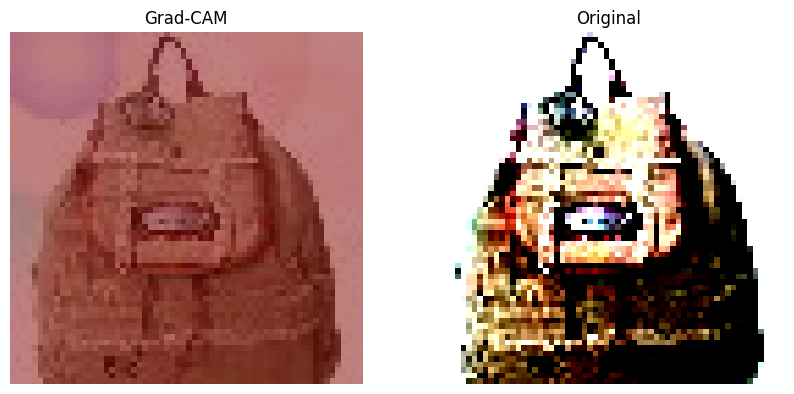

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.64].


Pred: 11, True: 44


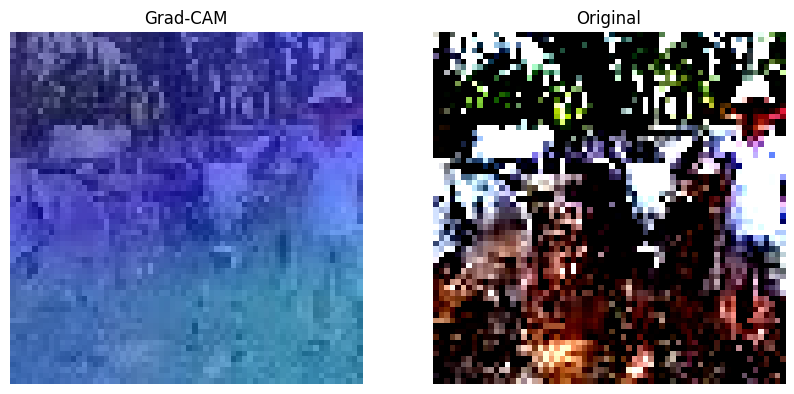

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8431373..2.64].


Pred: 152, True: 85


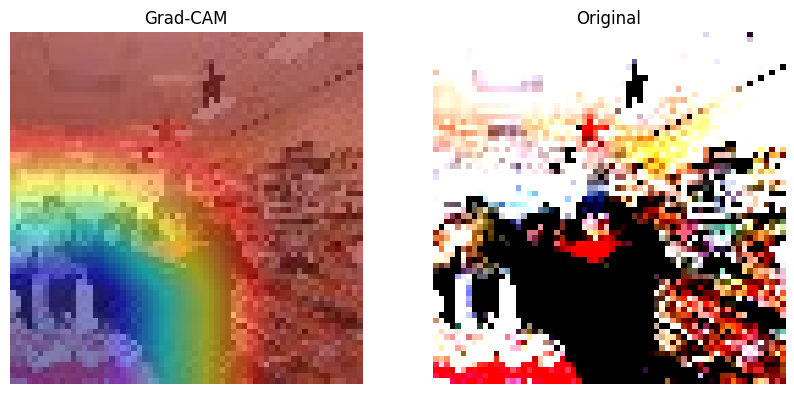

In [60]:
import random

model.eval()

for _ in range(4):  # 4 випадкові приклади
    idx = random.randint(0, len(valid_dataset) - 1)

    img, label = valid_dataset[idx]
    img = img.unsqueeze(0).to(device)

    heatmap, pred = compute_heatmap(model, img)
    overlay = upsampleHeatmap(heatmap, img)

    print(f"Pred: {pred}, True: {label}")

    display_images(overlay, img)

### Порівняння моделей: навчання з нуля vs transfer learning (ResNet18)

**Результати (10 епох):**

| Підхід            | Top-1 (val) | Top-5 (val) | F1 (val)   |
| ----------------- | ----------- | ----------- | ---------- |
| З нуля            | **0.3881**  | **0.6595**  | **0.3788** |
| Transfer learning | 0.3484      | 0.6064      | 0.3448     |

* У цьому експерименті модель, навчена з нуля, перевершила transfer learning за всіма основними метриками.
* Хоча transfer learning дає кращий старт завдяки попередньо навченим ознакам, у даному випадку він обмежений замороженими шарами, що стримує подальше покращення.
* Повне навчання моделі дозволило краще адаптуватися до специфіки датасету та вивчити більш релевантні ознаки.

**Динаміка навчання:**

* Transfer learning демонструє швидкий старт і вже з перших епох показує відносно високі значення метрик.
* Модель, навчена з нуля, стартує трохи гірше, але показує стабільне й значно сильніше покращення протягом навчання.
* Після ~5–6 епох модель "з нуля" обганяє TL і продовжує покращуватись, тоді як TL виходить на плато.

**Висновки:**

* У даному випадку навчання з нуля виявилось ефективнішим, ніж підхід "freeze + fc".
* Основна причина - краща адаптація всієї мережі, а не лише фінального шару.
* Transfer learning дає не сильно гірший результат, але потребує:
  - fine-tuning (розморожування частини шарів)
  - більш гнучкого налаштування learning rate
* Навчання з нуля є кращим вибором, якщо:
  - датасет достатньо великий
  - є ресурси для довшого тренування

**Але у деяких експериментах результати TL переважають.** \
Можливі причини цього:
* Результати змінюються через випадкову ініціалізацію ваг.
* Впливає перемішування (shuffle) даних у кожній епосі.
* Обчислення на GPU можуть бути недетермінованими.
* Малий горизонт навчання (10 епох)

## Transfer learning MobileNetV2

### Різниця між ResNet18 та MobileNetV2
- **ResNet18** використовує residual-блоки:  
  стиснення (1×1) -> згортка (3×3) -> відновлення (1×1) + skip connection.
- **MobileNetV2** використовує inverted residual блоки:  
  розширення (1×1) -> depthwise згортка (3×3) -> стиснення (1×1).
- **ResNet18** є більш важкою моделлю, але часто дає кращу точність.
- **MobileNetV2** значно легша та швидша завдяки depthwise separable convolutions, але може трохи поступатись у якості.

In [68]:
import torchvision.models as models
import torch.nn as nn

model = models.mobilenet_v2(pretrained=True)

/home/tym/kpi/neural_networks/nn_Lab3-4/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/tym/kpi/neural_networks/nn_Lab3-4/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [69]:
for param in model.parameters():
    param.requires_grad = False

In [70]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 200)

In [76]:
import os

# Директорія для збереження моделі
save_dir = "./models/mobilenet_v2"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR
import time


device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"device: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-5  # мінімальний LR
)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_top1": [],
    "val_top1": [],
}

for epoch in range(num_epochs):
    start_epoch = time.time()
    
    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()

    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics = evaluate(model, valid_loader, criterion, device)

    scheduler.step()
    
    epoch_time = time.time() - start_epoch

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_top1"].append(train_metrics["top1"])
    history["val_top1"].append(val_metrics["top1"])
    
    print(f"Epoch {epoch+1}/{num_epochs} | Time: {epoch_time:.2f}s")
    print(f"Train Loss: {train_metrics['loss']:.4f} | Top1: {train_metrics['top1']:.4f} | Top5: {train_metrics['top5']:.4f}")
    print(f"Val   Loss: {val_metrics['loss']:.4f} | Top1: {val_metrics['top1']:.4f} | Top5: {val_metrics['top5']:.4f} | F1: {val_metrics['f1']:.4f}")

    if device == "cuda":
        mem = torch.cuda.max_memory_allocated() / 1024**2
        print(f"GPU memory: {mem:.2f} MB")

# Збереження моделі
torch.save(model.state_dict(), f"{save_dir}/tl_mobilenet_v2.pth")

device: cuda


Epoch 1/10 | Time: 85.18s
Train Loss: 3.8128 | Top1: 0.2145 | Top5: 0.4350
Val   Loss: 3.5677 | Top1: 0.2530 | Top5: 0.5070 | F1: 0.2509
GPU memory: 404.54 MB


Epoch 2/10 | Time: 82.31s
Train Loss: 3.6327 | Top1: 0.2473 | Top5: 0.4847
Val   Loss: 3.5568 | Top1: 0.2670 | Top5: 0.5182 | F1: 0.2629
GPU memory: 404.54 MB


Epoch 3/10 | Time: 85.34s
Train Loss: 3.6090 | Top1: 0.2527 | Top5: 0.4927
Val   Loss: 3.4331 | Top1: 0.2827 | Top5: 0.5313 | F1: 0.2766
GPU memory: 404.54 MB


Epoch 4/10 | Time: 82.96s
Train Loss: 3.5489 | Top1: 0.2582 | Top5: 0.4999
Val   Loss: 3.3759 | Top1: 0.2899 | Top5: 0.5359 | F1: 0.2823
GPU memory: 404.54 MB


...

Epoch 6/10 | Time: 82.45s
Train Loss: 3.4133 | Top1: 0.2752 | Top5: 0.5199
Val   Loss: 3.2686 | Top1: 0.2965 | Top5: 0.5509 | F1: 0.2903
GPU memory: 404.54 MB


Epoch 7/10 | Time: 86.03s
Train Loss: 3.3375 | Top1: 0.2817 | Top5: 0.5294
Val   Loss: 3.2029 | Top1: 0.2986 | Top5: 0.5599 | F1: 0.2875
GPU memory: 404.54 MB


Epoch 8/10 | Time: 82.69s
Train Loss: 3.2617 | Top1: 0.2909 | Top5: 0.5426
Val   Loss: 3.1356 | Top1: 0.3150 | Top5: 0.5737 | F1: 0.3092
GPU memory: 404.54 MB


Epoch 9/10 | Time: 82.41s
Train Loss: 3.2185 | Top1: 0.2975 | Top5: 0.5480
Val   Loss: 3.0911 | Top1: 0.3218 | Top5: 0.5779 | F1: 0.3172
GPU memory: 404.54 MB


Epoch 10/10 | Time: 81.80s
Train Loss: 3.1898 | Top1: 0.3013 | Top5: 0.5535
Val   Loss: 3.0981 | Top1: 0.3191 | Top5: 0.5743 | F1: 0.3141
GPU memory: 404.54 MB


### Performance
*(#параметрів (М), FLOPs (Г), latency інференсу (CPU/GPU))*

In [78]:
flops, params = get_model_stats(model, device)

print(f"Params: {params:.2f} M")
print(f"FLOPs: {flops:.2f} GFLOPs")

Params: 2.48 M
FLOPs: 0.03 GFLOPs


In [79]:
lat_gpu = measure_latency(model, "cuda") if torch.cuda.is_available() else None
lat_cpu = measure_latency(model.to("cpu"), "cpu")

print(f"Latency CPU: {lat_cpu:.2f} ms")
if lat_gpu:
    print(f"Latency GPU: {lat_gpu:.2f} ms")

Latency CPU: 6.57 ms
Latency GPU: 6.76 ms


### Результати

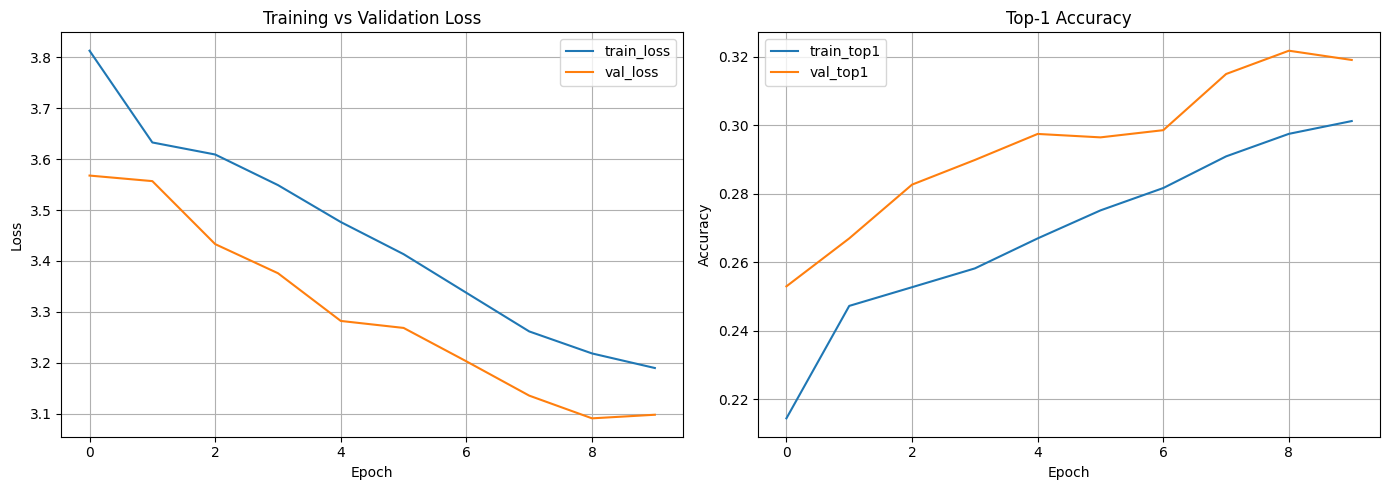

In [80]:
plt.figure(figsize=(14,5))

# Графік loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

# Графік accuracy
plt.subplot(1, 2, 2)
plt.plot(history["train_top1"], label="train_top1")
plt.plot(history["val_top1"], label="val_top1")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Top-1 Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

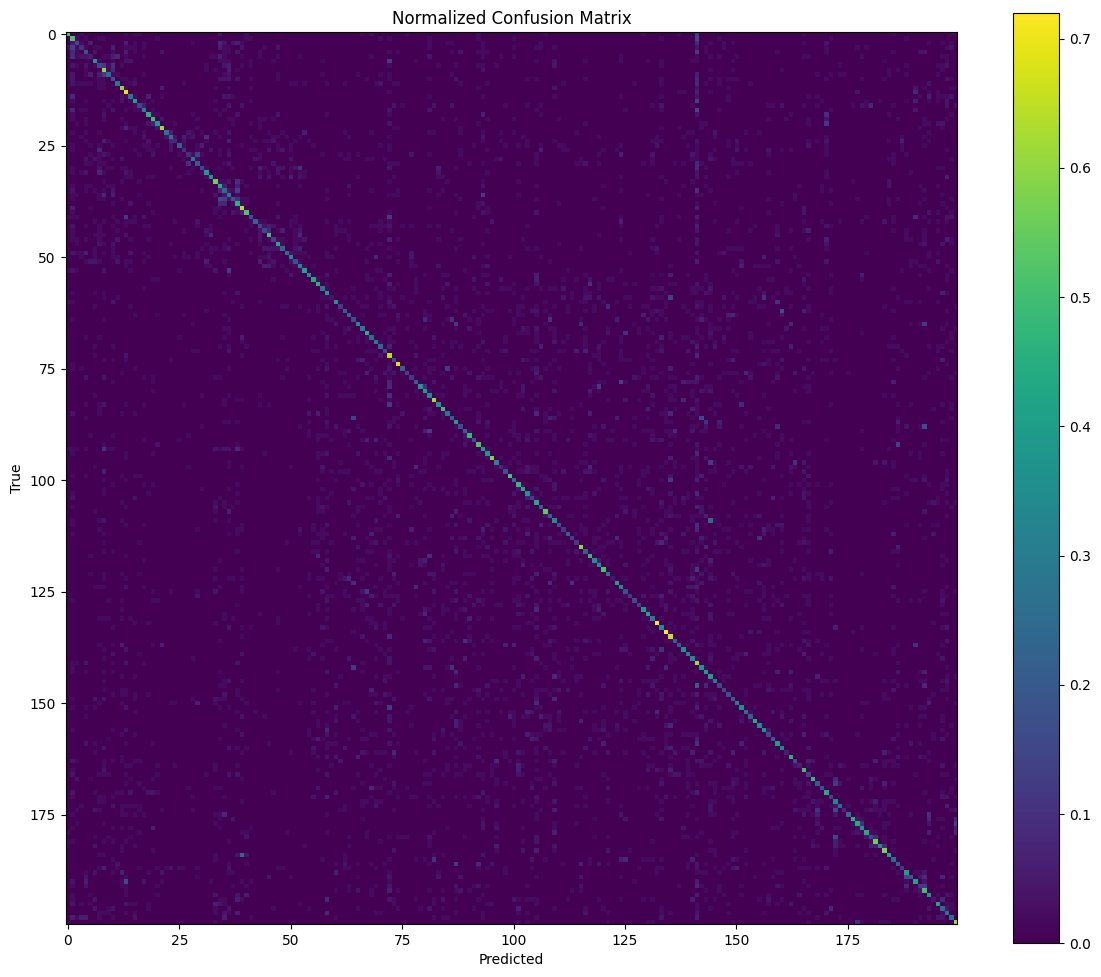

In [81]:
cm = val_metrics["confusion_matrix"]

# нормалізація по рядках (true labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, interpolation='nearest')
plt.title("Normalized Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

### Grad-CAM

In [82]:
target_layer = model.features[-1]

In [83]:
def compute_heatmap(model, img):
    model.to(device)
    model.eval()

    img = img.clone().detach().requires_grad_(True)

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    logits = model(img)
    pred = logits.argmax(dim=1).item()

    model.zero_grad(set_to_none=True)
    logits[0, pred].backward()

    if len(activations) == 0 or len(gradients) == 0:
        handle_f.remove()
        handle_b.remove()
        raise RuntimeError("Hooks did not capture activations/gradients.")

    acts = activations[0]
    grads = gradients[0]

    weights = grads.mean(dim=(2, 3), keepdim=True)
    heatmap = (weights * acts).sum(dim=1)[0]
    heatmap = torch.relu(heatmap)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    handle_f.remove()
    handle_b.remove()

    return heatmap.detach().cpu(), pred

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5005665].


Pred: 159, True: 60


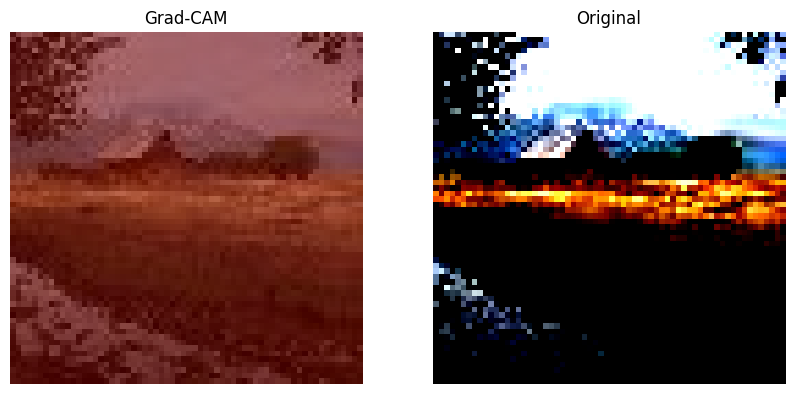

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3262744].


Pred: 93, True: 157


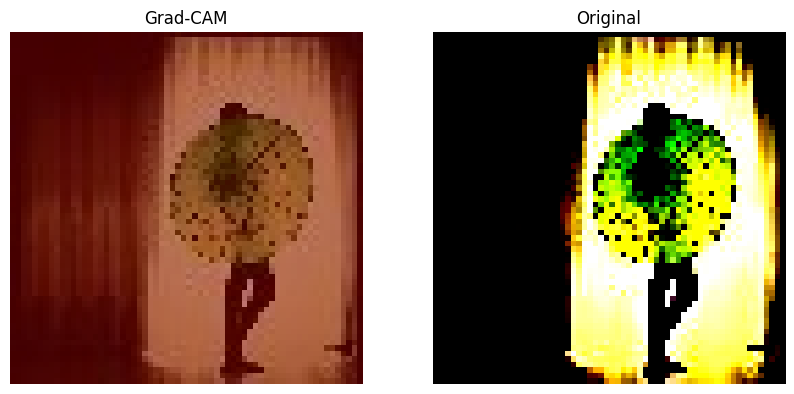

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Pred: 188, True: 188


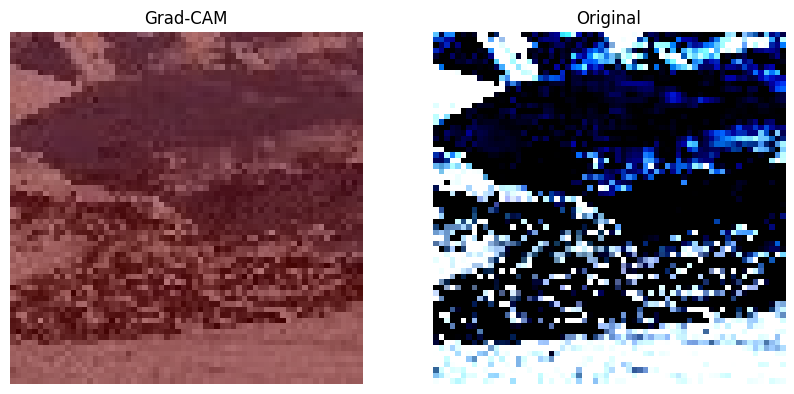

Pred: 105, True: 62


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].


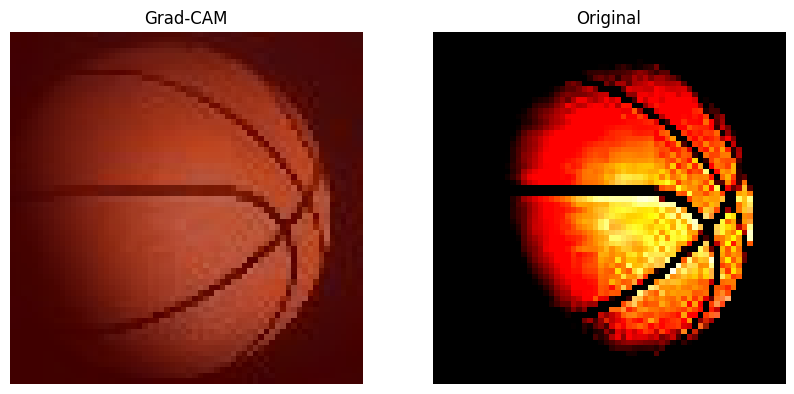

In [86]:
import random

model.eval()

for _ in range(4):  # 4 випадкові приклади
    idx = random.randint(0, len(valid_dataset) - 1)

    img, label = valid_dataset[idx]
    img = img.unsqueeze(0).to(device)

    heatmap, pred = compute_heatmap(model, img)
    overlay = upsampleHeatmap(heatmap, img)

    print(f"Pred: {pred}, True: {label}")

    display_images(overlay, img)